# FLI Simulation for mimicking the time-resolved image acquisition

This example simulates a full 3-D fluorescence lifetime image dataset by combining a binary intensity mask (for a specific image structure) with a multi-region ("multi-ROI") label mask, so different regions of the image can be assigned independent simulator configurations for region-specific lifetime variation.

This example walks through:
- loading data
- setting the imaging-instrument parameters (laser repetition rate, acquisition delay, etc.)
- choosing the sample type (mono-exponential, bi-exponential, or a mixture of both decay models)
- configuring detector / noise settings (jitter, dark counts, shot noise, quantization)
- defining per-region simulator configs and assembling them with `FLIModelImageGenerator`
- generating the full decay / fit / IRF cubes and per-pixel parameter maps, and
- visualizing the resulting lifetime, photon-count, and mono/bi-exponential maps, and probing a single pixel's decay trace

<small>Author - Vikas</small>


In [2]:
## importing the modules required for this work
import sys

sys.path.insert(0, "ex_helper")


from sim_general_image import LettersShape, ROIMaskGenerator

from pyfli.analysis.utils import random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.io import DataOperations
from pyfli.simulator import FLIModelImageGenerator

## Generating an image with a custom shape function

In this example, a 128 x 512 image is generated with the letters "F", "L", "I", "M". Each letter is assigned a different intensity value (grayscale bit size) and a different lifetime: 0.7 ± 0.05 ns, 0.8 ± 0.05 ns, 0.9 ± 0.05 ns, and 1.0 ± 0.05 ns, respectively.

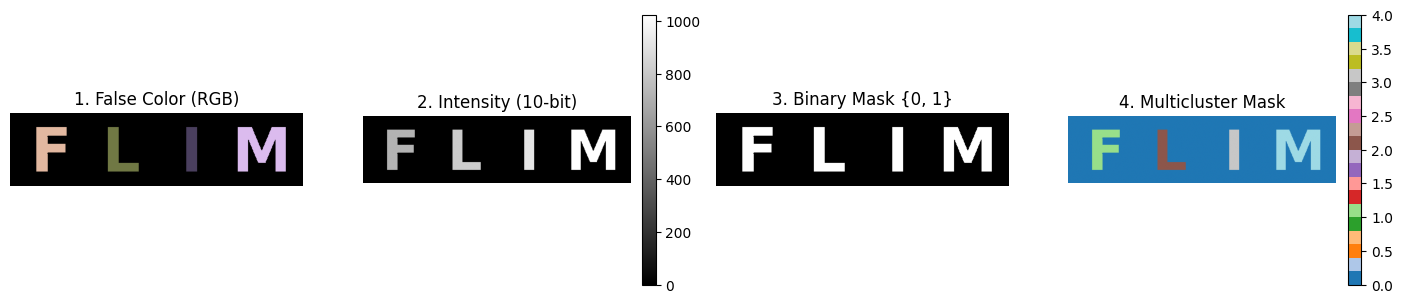

(<Figure size 1400x350 with 6 Axes>,
 array([<Axes: title={'center': '1. False Color (RGB)'}>,
        <Axes: title={'center': '2. Intensity (10-bit)'}>,
        <Axes: title={'center': '3. Binary Mask {0, 1}'}>,
        <Axes: title={'center': '4. Multicluster Mask'}>], dtype=object))

In [3]:
h, w = 128, 512
generator = ROIMaskGenerator((h, w), top=10, bottom=10, left=10, right=10)
FLIM_letters = LettersShape(
    letters=("F", "L", "I", "M"),
    gap=0.15,
)

custom_intensities = [0.7, 0.8, 0.9, 1.0]
# This generates the preview of the generated images
generator.plot_preview(
    FLIM_letters,
    bit_depth=10,
    intensities=custom_intensities,
    show=True,
)

In [ ]:
IRF_PATH = "<select file/folder path>"

In [5]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


In [6]:
# select the type of decay model to simulate
MODEL_TYPE = "mono-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4  # fraction of mono-exponential model in sampled data


# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": mono_fraction,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

Different ROIs (letter areas, in this case) are assigned different lifetimes.

In [7]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


ROI0 = {}
ROI1 = get_config(
    tau2_beta_range=(0.05, 0.5),
)
ROI2 = get_config(
    tau2_beta_range=(0.05, 0.7),
)
ROI3 = get_config(
    tau2_beta_range=(0.05, 0.9),
)
ROI4 = get_config(
    tau2_beta_range=(0.05, 1.1),
)

In [8]:
img_color = generator.generate_color_image(FLIM_letters)
img_intensity = generator.generate_intensity_image(
    FLIM_letters, intensities=custom_intensities
)
img_cluster = generator.generate_cluster_mask(FLIM_letters)
b_bool_mask = generator.generate_binary_mask(FLIM_letters)

simulated_img = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity,
    roi_mask=img_cluster,
    roi_params=[ROI0, ROI1, ROI2, ROI3, ROI4],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask,
)

gt_data = simulated_img.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


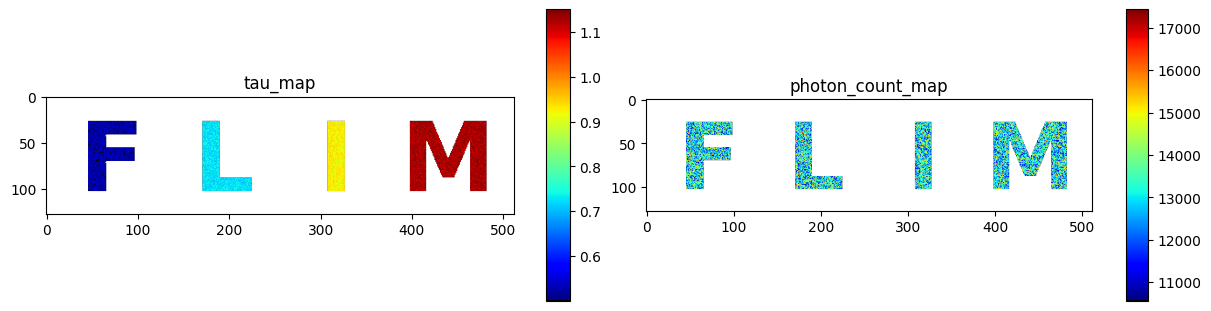

In [9]:
res = gt_data["results"]["maps"]
if MODEL_TYPE == "bi-exponential":
    data_list = [
        res["tau1_map"],
        res["tau2_map"],
        res["alpha1_map"],
        res["A1_map"],
        res["A2_map"],
        res["fret_efficiency_map"],
        res["tau_mean_map"],
        res["photon_count_map"],
        res["mono_map"],
    ]
    data_names = [
        "tau1_map",
        "tau2_map",
        "alpha1_map",
        "A1_map",
        "A2_map",
        "fret_efficiency_map",
        "tau_mean_map",
        "photon_count_map",
        "mono_map",
    ]
    rows = 3
    fig_size = (13, 9)
else:
    data_list = [res["tau_map"], res["photon_count_map"]]
    data_names = ["tau_map", "photon_count_map"]
    rows = 1
    fig_size = (12, 3)
jet_m = ColorProcessor().lowest_zero("jet")
cmaps = [jet_m] * len(data_list)
v_ranges = None
px = None

if px is None:
    cols = int(len(data_list) / rows)
else:
    cols = int(len(data_list) / rows) + 1


_ = DataViewer().display_data(
    data_list,
    structure=(rows, cols),
    coord=px,
    data_names=data_names,
    cmaps=cmaps,
    v_ranges=v_ranges,
    figsize=fig_size,
    normalize=False,
    yscale="linear",
)

the non-zero pixel selected for probing is (91, 222)


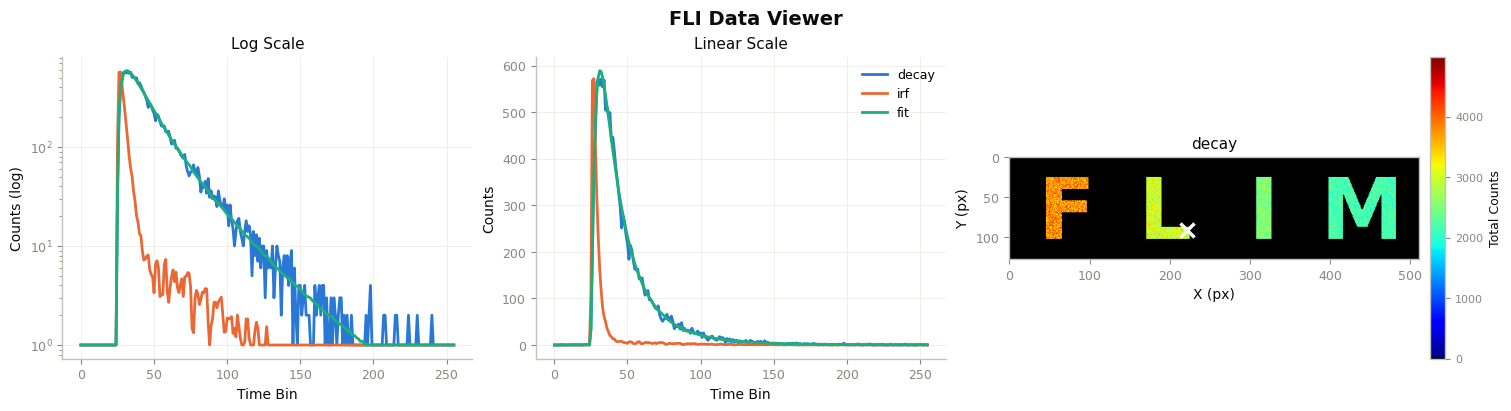

INFO:pyfli:
  Pixel (91, 222)
  ─────────────────────
  A         15003.2695
  α         —
  τ₁        0.7493
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   —
  h-shift   —
  ─────────────────────



In [10]:
sim_decay = gt_data["raw_data"]["decay"]
sim_irf = gt_data["raw_data"]["irf"]
x, y = random_true_pixel(b_bool_mask)
TRs = gt_data["results"]["TR_maps"]
maps = gt_data["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(sim_irf).norm_scale(sim_decay)
DataViewer().plot_fli_px(
    data_list=[sim_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
    pixel=(x, y),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x, y))